# Augmented Scene Generation

This notebook creates synthetic UNO scenes from the extracted reference-card crops.
Each scene contains 0 to 6 cards for each player, one center card, and one active-player token.
It saves RGB scenes under `training_images/augmented_scenes` and card segmentation masks under `training_masks/augmented_scenes`.

Masks are generated from per-card visible instances, then each instance is slightly eroded before the final binary mask is written. This creates a small black gap between overlapping cards so a segmenter can learn clean card boundaries.

## Path setup


In [1]:
from pathlib import Path
import sys

candidate_src_dirs = [
    Path.cwd() / "src",
    Path.cwd().parent.parent / "src",
]
for src_dir in candidate_src_dirs:
    if src_dir.is_dir():
        parent = src_dir.parent.resolve()
        if str(parent) not in sys.path:
            sys.path.insert(0, str(parent))
        break
else:
    raise FileNotFoundError("Could not locate do/src directory for imports.")


## Imports


In [2]:
from src.create_augmented_data import (
    CreateAugmentedDataConfig,
    initialize_create_augmented_data_pipeline,
    plot_card_preview,
    plot_saved_scenes,
    plot_scene_preview,
    run_card_generation,
    run_scene_generation,
    run_scene_preview,
)


/Users/dorianbesson/EDOC/IA/iapr2026do/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration


In [3]:
# Most-used quick knobs
SEED = 67
N_AUG_PER_REFERENCE = 200
N_SCENES = 4096
SCENE_SIZE = (1280, 720)
MAX_CARDS_PER_PLAYER = 4
MASK_GAP_PIXELS = 5
PLAYER_CARD_HEIGHT_RANGE = (0.20, 0.22)
CENTER_CARD_HEIGHT_RANGE = (0.20, 0.22)
PLAYER_ROTATION_JITTER_DEG_RANGE = (4.0, 45.0)

# RGB output compression knobs (masks remain lossless PNG).
CARD_IMAGE_FORMAT = "jpg"
CARD_JPEG_QUALITY = 85
SCENE_IMAGE_FORMAT = "jpg"
SCENE_JPEG_QUALITY = 83

CFG = CreateAugmentedDataConfig(
    seed=SEED,
    n_aug_per_reference=N_AUG_PER_REFERENCE,
    n_scenes=N_SCENES,
    scene_width=SCENE_SIZE[0],
    scene_height=SCENE_SIZE[1],
    max_cards_per_player=MAX_CARDS_PER_PLAYER,
    mask_gap_pixels=MASK_GAP_PIXELS,
    player_card_height_fraction_range=PLAYER_CARD_HEIGHT_RANGE,
    center_card_height_fraction_range=CENTER_CARD_HEIGHT_RANGE,
    player_rotation_jitter_deg_range=PLAYER_ROTATION_JITTER_DEG_RANGE,
    aug_card_image_format=CARD_IMAGE_FORMAT,
    aug_card_jpeg_quality=CARD_JPEG_QUALITY,
    scene_image_format=SCENE_IMAGE_FORMAT,
    scene_jpeg_quality=SCENE_JPEG_QUALITY,
)
CFG

CreateAugmentedDataConfig(seed=67, n_aug_per_reference=200, aug_card_canvas=(256, 256), aug_card_height_range=(140, 220), aug_card_angle_range_deg=(-25.0, 25.0), aug_card_shift_fraction=0.12, aug_card_image_format='jpg', aug_card_jpeg_quality=85, n_scenes=4096, scene_width=1280, scene_height=720, min_cards_per_player=0, max_cards_per_player=4, mask_gap_pixels=5, min_visible_card_area=90, clear_output_dirs=True, player_card_height_fraction_range=(0.2, 0.22), center_card_height_fraction_range=(0.2, 0.22), player_slot_spacing_factor_range=(0.12, 1.5), player_hand_center_jitter_fraction_range=(0.006, 0.02), player_slot_offset_jitter_fraction_range=(0.05, 0.2), player_inward_jitter_fraction_range=(0.008, 0.03), player_rotation_jitter_deg_range=(4.0, 45.0), center_position_fraction_range_x=(0.4, 0.7), center_position_fraction_range_y=(0.4, 0.7), center_angle_range_deg=(-70.0, 70.0), scene_image_format='jpg', scene_jpeg_quality=83, token_inward_distance_fraction_range=(0.0, 0.05), token_later

## Initialize pipeline

Loads reference card crops, prepares output directories, and primes background/token caches.


In [4]:
state = initialize_create_augmented_data_pipeline(CFG)
state.keys()


Project root: /Users/dorianbesson/EDOC/IA/iapr2026do
Reference cards: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/training_images/reference_cards
Reference labels: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/object_labels/reference_cards/reference_do.csv
Funky background: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/funky_bg.jpg
White background: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/white_bg.jpg
Augmented cards: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/training_images/augmented_cards
Augmented card masks: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/training_masks/augmented_cards
Augmented labels: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/object_labels/augmented_cards/aug.csv
Scene images: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/training_images/augmented_scenes
Scene masks: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/trai

dict_keys(['cfg', 'paths', 'caches', 'card_assets', 'labels', 'aug_rows', 'scene_metadata', 'preview_scene_bgr', 'preview_mask', 'preview_metadata', 'card_preview_rng'])

## Generate single-card augmentations

Creates `aug_*.jpg` crops for classifier training and the matching `aug.csv` labels file.


In [5]:
state = run_card_generation(state)
len(state["aug_rows"])


100%|██████████| 10800/10800 [00:44<00:00, 244.61it/s]

Saved 10800 augmented cards to: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/training_images/augmented_cards
Saved 10800 augmented card masks to: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/training_masks/augmented_cards
Saved augmented labels to: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/object_labels/augmented_cards/aug.csv


10800

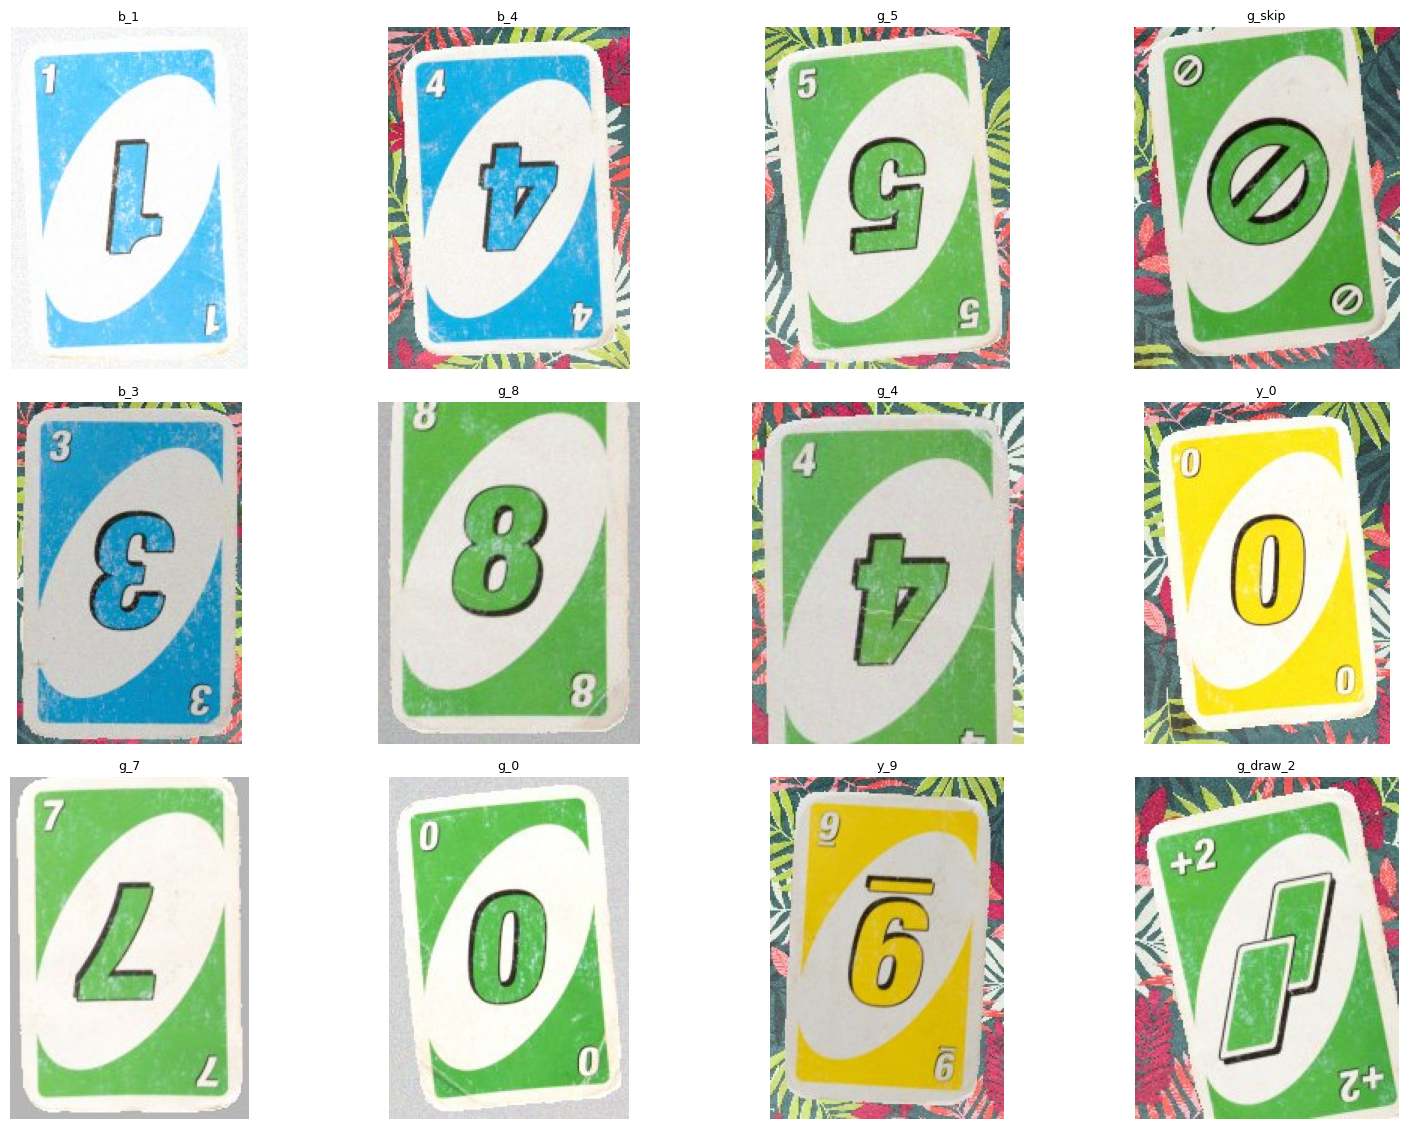

In [6]:
plot_card_preview(state)


## Preview a synthetic scene

Compose one scene in-memory before kicking off the full generation pass.


In [7]:
state = run_scene_preview(state)
state["preview_metadata"]["style"], state["preview_metadata"]["active_player"]


('white_rect', 'p2')

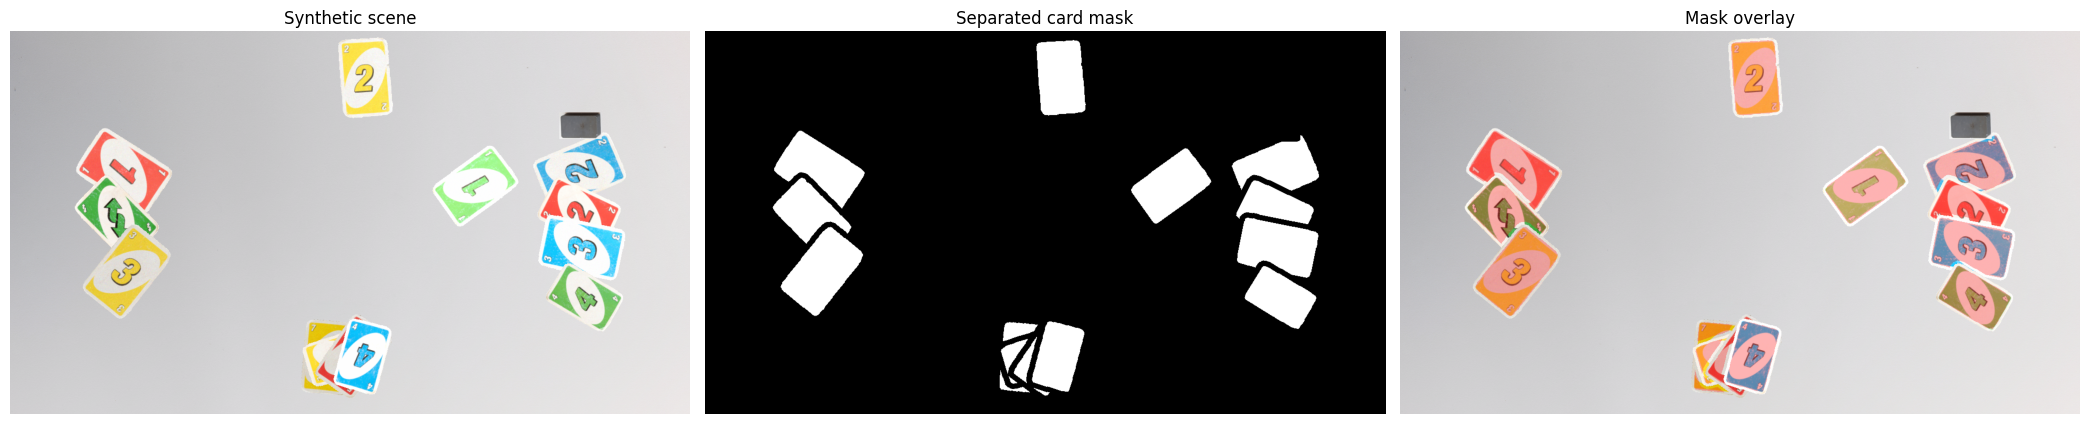

{
  "style": "white_rect",
  "active_player": "p2",
  "player_card_counts": {
    "p1": 4,
    "p2": 4,
    "p3": 1,
    "p4": 3
  },
  "visible_cards": 13,
  "token_source": "/Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/training_images/token_crops/white_rectangular_black/p2/left_rect.png"
}


In [8]:
plot_scene_preview(state)


## Generate the augmented scene dataset


In [9]:
state = run_scene_generation(state)
len(state["scene_metadata"])


100%|██████████| 4096/4096 [03:51<00:00, 17.72it/s]


Saved 4096 scenes to: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/training_images/augmented_scenes
Saved 4096 masks to:  /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/training_masks/augmented_scenes
Saved scene metadata to:   /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/object_labels/augmented_scenes/labels.json


4096

## Visual check of saved scenes


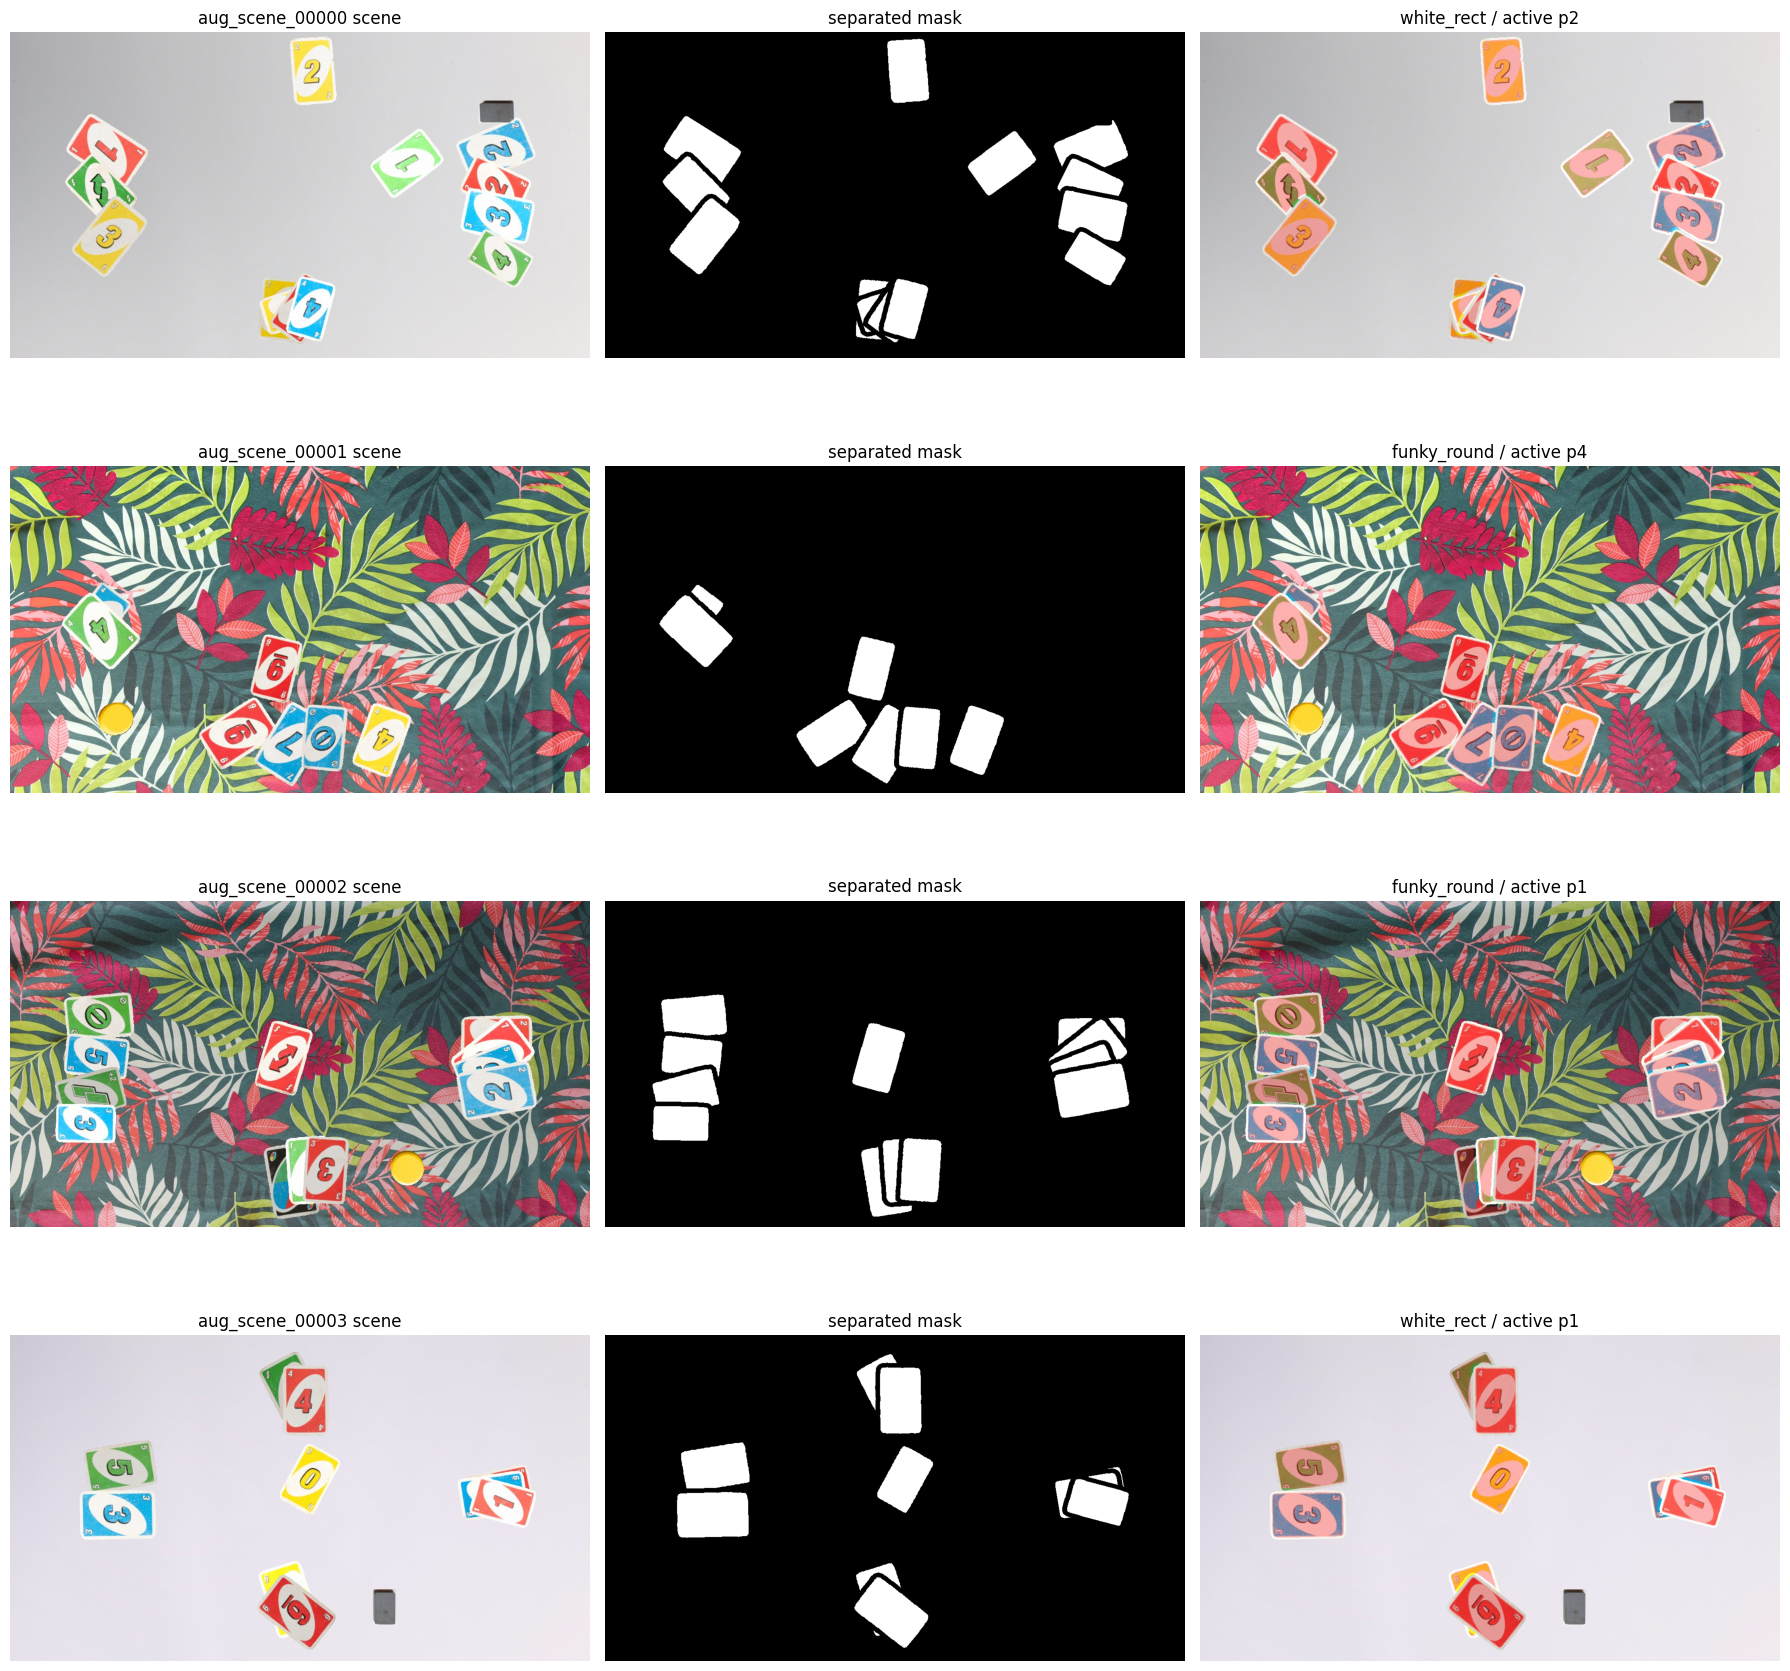

Previewed 4 saved samples from /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/object_labels/augmented_scenes/labels.json


In [10]:
plot_saved_scenes(state)
